In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
jabs = pd.read_csv('../data/jabs.csv',encoding = 'utf-16')
hooks = pd.read_csv('../data/hooks.csv', encoding = 'utf-16')
uppercuts = pd.read_csv('../data/uppercuts_left.csv', encoding = 'utf-16')

# Vi arbejder med jabs som eksempel — gentag for de andre
df_jab = jabs
df_hooks = hooks
df_uppercuts = uppercuts
df_jab.head()

,timestamp,accX,accY,accZ,totalAcc,marker
0,15569,-785,-457,-308,959,0
1,15579,-789,-464,-312,967,0
2,15589,-789,-468,-300,965,0
3,15599,-785,-460,-304,960,0
4,15609,-781,-460,-304,956,0


In [2]:
df_jab.describe()

,timestamp,accX,accY,accZ,totalAcc,marker
count,10066.000000,10066.000000,10066.000000,10066.000000,10066.000000,10066.000000
mean,65894.000000,-339.319491,103.305981,-487.835585,1930.177926,0.444765
std,29059.482388,1863.381877,1106.504455,803.392933,1407.369974,0.496964
min,15569.000000,-5476.000000,-6621.000000,-6011.000000,151.000000,0.000000
25%,40731.500000,-1238.000000,-406.000000,-671.000000,1051.000000,0.000000
50%,65894.000000,-863.000000,125.000000,-378.000000,1395.500000,0.000000
75%,91056.500000,-265.000000,699.000000,-85.000000,2328.750000,1.000000
max,116219.000000,10125.000000,5058.000000,2734.000000,10835.000000,1.000000


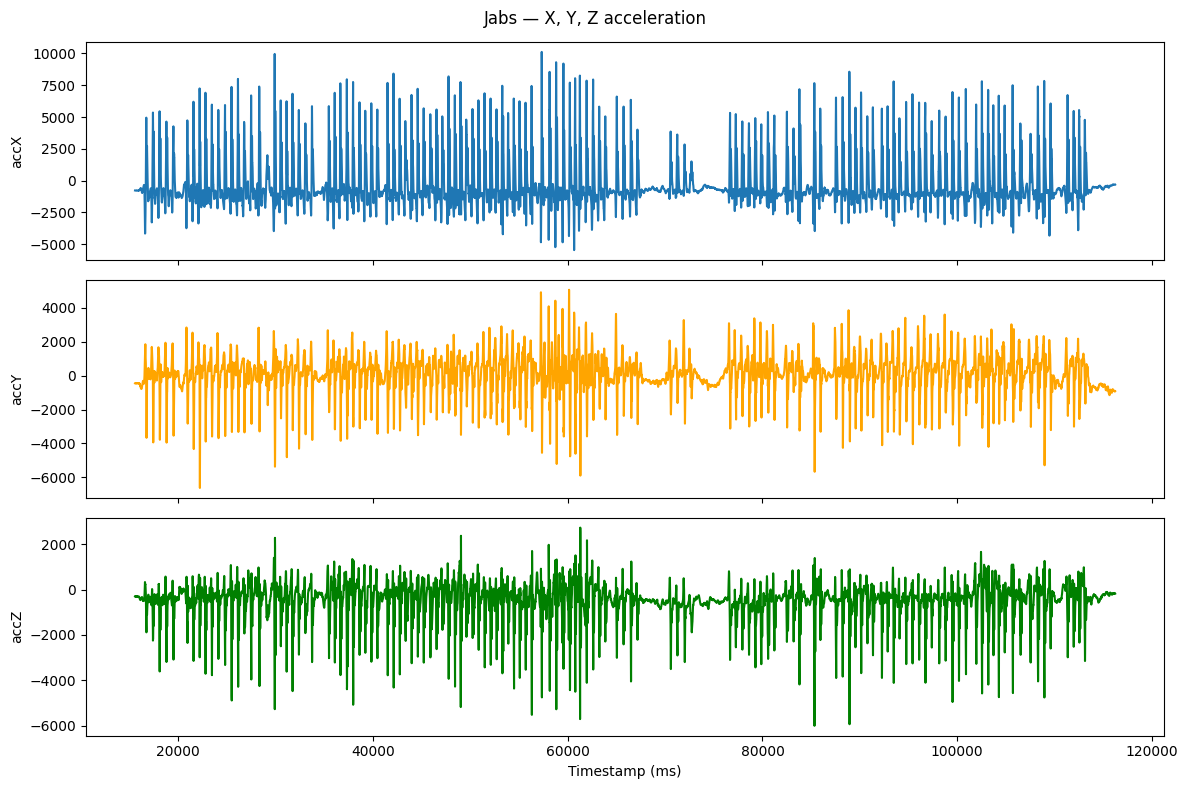

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df_jab['timestamp'], df_jab['accX'], label='X')
axes[0].set_ylabel('accX')

axes[1].plot(df_jab['timestamp'], df_jab['accY'], label='Y', color='orange')
axes[1].set_ylabel('accY')

axes[2].plot(df_jab['timestamp'], df_jab['accZ'], label='Z', color='green')
axes[2].set_ylabel('accZ')

axes[2].set_xlabel('Timestamp (ms)')
plt.suptitle('Jabs — X, Y, Z acceleration')
plt.tight_layout()
plt.show()

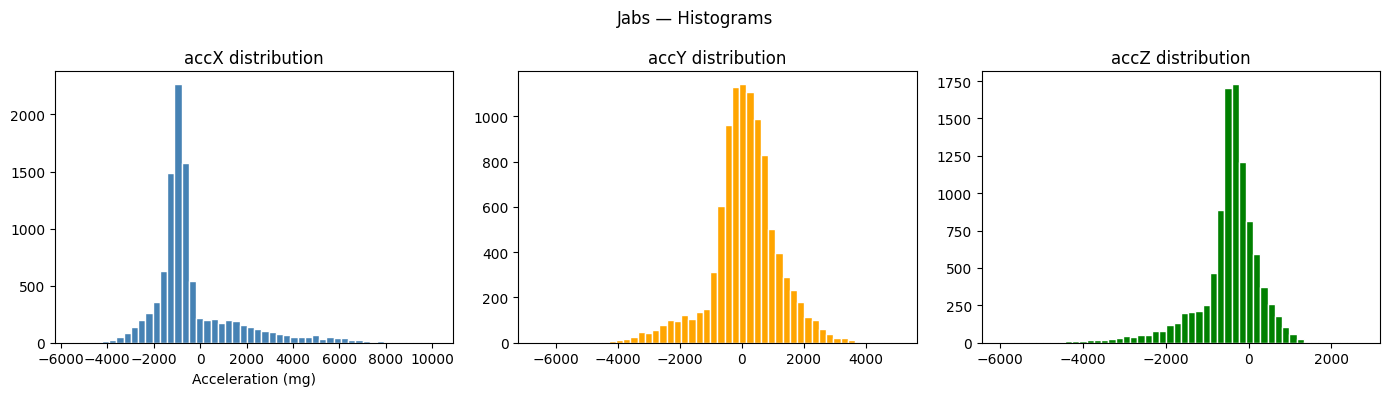

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_jab['accX'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('accX distribution')
axes[0].set_xlabel('Acceleration (mg)')

axes[1].hist(df_jab['accY'], bins=50, color='orange', edgecolor='white')
axes[1].set_title('accY distribution')

axes[2].hist(df_jab['accZ'], bins=50, color='green', edgecolor='white')
axes[2].set_title('accZ distribution')

plt.suptitle('Jabs — Histograms')
plt.tight_layout()
plt.show()

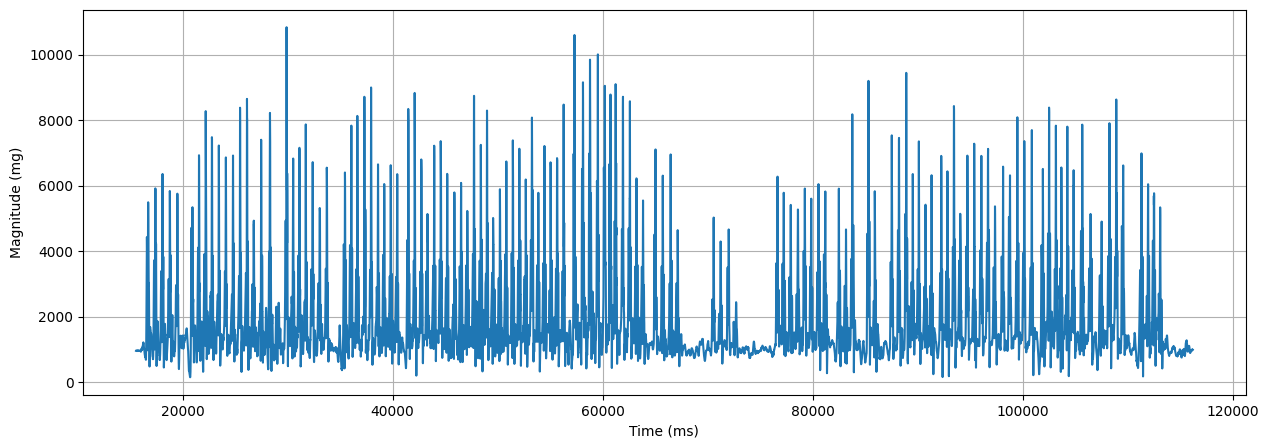

In [6]:
# udregner magnitude, er godt nok gjort i c++ men udregnet for at være sikker på at det er korrekt og for at kunne plotte det i python
df_jab["mag"] = np.sqrt(
    df_jab["accX"]**2 +
    df_jab["accY"]**2 +
    df_jab["accZ"]**2
)

plt.figure(figsize=(15,5))
plt.plot(df_jab["timestamp"], df_jab["mag"])
plt.ylabel("Magnitude (mg)")
plt.xlabel("Time (ms)")
plt.grid()
plt.show()

In [7]:
#find peaks i dataen, det er her der er slag

from scipy.signal import find_peaks

peaks, properties = find_peaks(
    df_jab["mag"],
    height=2000,      # minimum peak
    distance=50       # mindst 50 samples mellem slag
)

print("Antal peaks:", len(peaks))

Antal peaks: 127


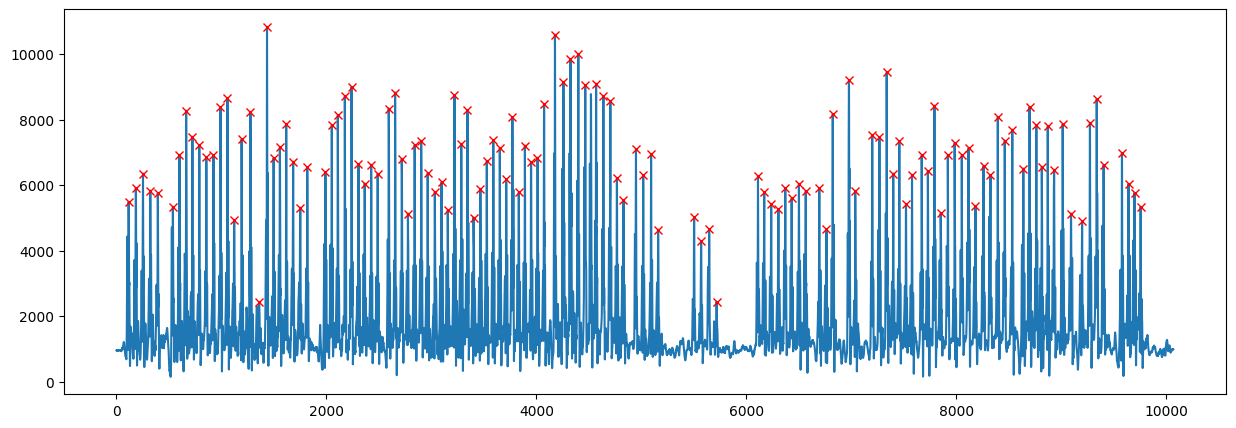

In [8]:
plt.figure(figsize=(15,5))

plt.plot(df_jab["mag"])
plt.plot(peaks,
         df_jab["mag"].loc[peaks],
         "rx")

plt.show()

In [9]:
# klipper hvert slag ud i et vindue, size kan variere afhængig af hvor lange slagene er
BEFORE_PEAK = 20  # hvor mange samples før peak
AFTER_PEAK = 15   # hvor mange samples efter peak
segments_jabs = []

for peak in peaks:
    start = peak - BEFORE_PEAK
    end = peak + AFTER_PEAK
    
    if start < 0:
        continue
    if end > len(df_jab):
        continue
    
    segment = df_jab.iloc[start:end].copy()
    segments_jabs.append(segment)
    
print(f"Antal segmenter: {len(segments_jabs)}")

Antal segmenter: 127


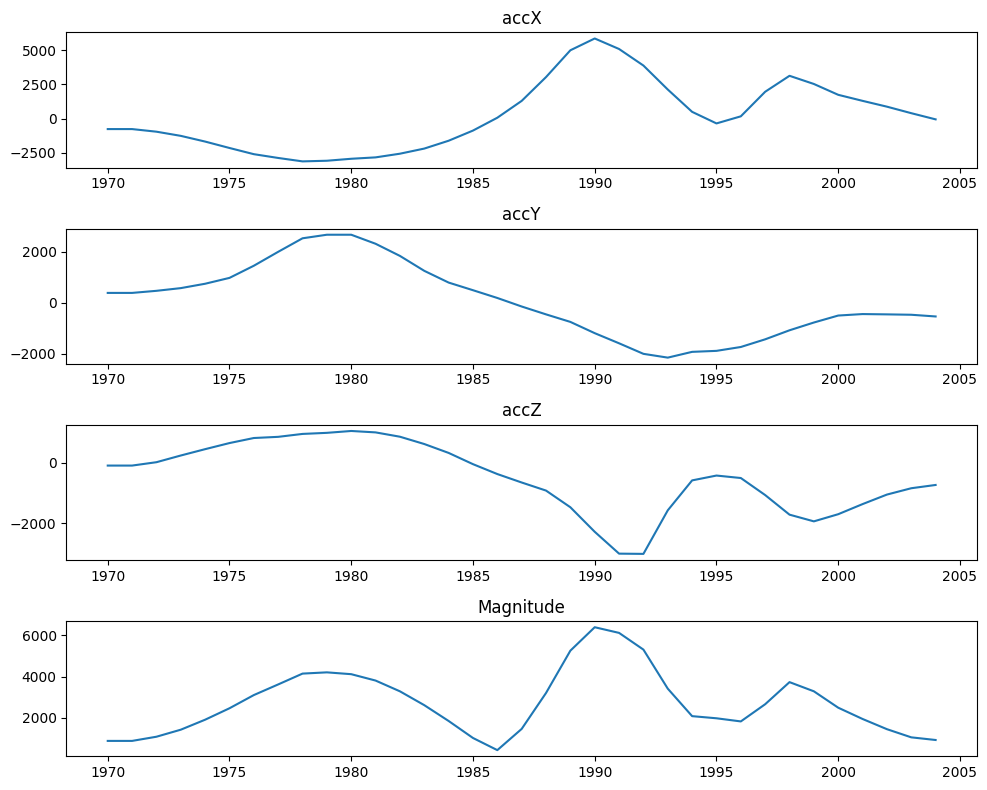

In [10]:
seg = segments_jabs[25]  # eksempel på et segment

fig, axes = plt.subplots(4,1, figsize=(10,8))

axes[0].plot(seg["accX"])
axes[0].set_title("accX")

axes[1].plot(seg["accY"])
axes[1].set_title("accY")

axes[2].plot(seg["accZ"])
axes[2].set_title("accZ")

axes[3].plot(seg["mag"])
axes[3].set_title("Magnitude")

plt.tight_layout()
plt.show()

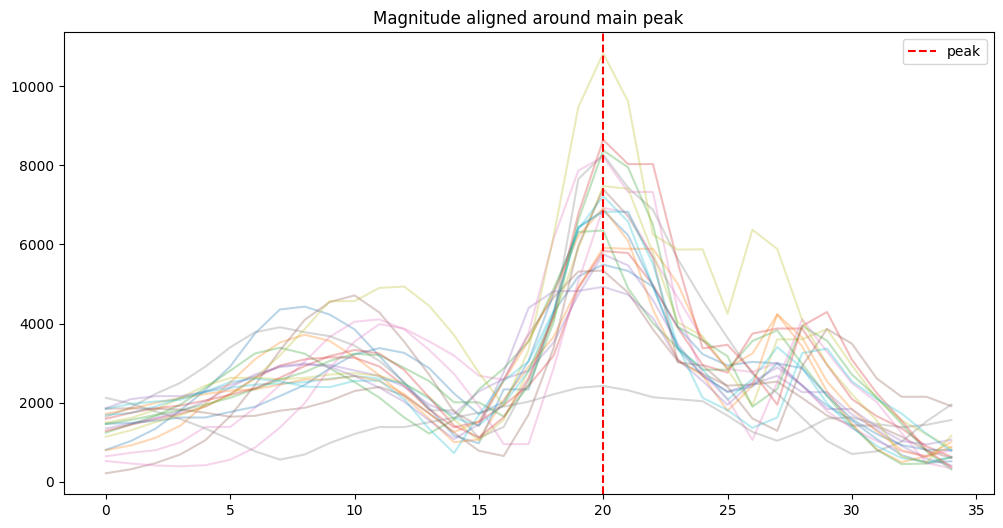

In [11]:
plt.figure(figsize=(12, 6))

for seg in segments_jabs[:20]:
    plt.plot(seg["mag"].values, alpha=0.3)

plt.axvline(BEFORE_PEAK, color="red", linestyle="--", label="peak")
plt.legend()
plt.title("Magnitude aligned around main peak")
plt.show()

In [12]:
#funktion til at udtrække features fra hvert segment, kan udvides med flere features
def extract_features(segment):

    features = [

        # accX
        segment["accX"].mean(),
        segment["accX"].std(),
        segment["accX"].max(),
        segment["accX"].min(),
        segment["accX"].skew(),
        np.sqrt(np.mean(segment["accX"]**2)),  # RMS

        # accY
        segment["accY"].mean(),
        segment["accY"].std(),
        segment["accY"].max(),
        segment["accY"].min(),
        segment["accY"].skew(),
        np.sqrt(np.mean(segment["accY"]**2)),  # RMS

        # accZ
        segment["accZ"].mean(),
        segment["accZ"].std(),
        segment["accZ"].max(),
        segment["accZ"].min(),
        segment["accZ"].skew(),
        np.sqrt(np.mean(segment["accZ"]**2)),  # RMS

        # Magnitude
        segment["mag"].mean(),
        segment["mag"].std(),
        segment["mag"].max(),
        segment["mag"].skew(),
        np.sqrt(np.mean(segment["mag"]**2)),   # RMS
    ]

    return features


In [13]:
features_jabs = []

for seg in segments_jabs:
    features_jabs.append(extract_features(seg))

In [14]:
feature_names = [

    "accX_mean",
    "accX_std",
    "accX_max",
    "accX_min",
    "accX_skew",
    "accX_rms",

    "accY_mean",
    "accY_std",
    "accY_max",
    "accY_min",
    "accY_skew",
    "accY_rms",

    "accZ_mean",
    "accZ_std",
    "accZ_max",
    "accZ_min",
    "accZ_skew",
    "accZ_rms",

    "mag_mean",
    "mag_std",
    "mag_max",
    "mag_skew",
    "mag_rms",
]

features_jabs_df = pd.DataFrame(features_jabs, columns=feature_names)
features_jabs_df["label"] = "jab"
features_jabs_df.head()

,accX_mean,accX_std,accX_max,accX_min,accX_skew,accX_rms,accY_mean,accY_std,accY_max,accY_min,...,accZ_max,accZ_min,accZ_skew,accZ_rms,mag_mean,mag_std,mag_max,mag_skew,mag_rms,label
0,169.800000,2656.220499,4949,-4175,0.008771,2623.500230,-107.457143,1441.750128,1847,-3667,...,332,-1886,-0.624105,794.458756,2720.034225,1486.356012,5490.751770,0.229077,3089.452836,jab
1,492.828571,2531.800109,5351,-3296,0.292919,2543.570050,-34.000000,1519.830873,1691,-3937,...,23,-2250,-0.931194,1011.102015,2704.372113,1579.484630,5914.913102,0.520167,3120.436032,jab
2,428.085714,2316.745719,5449,-2945,0.403794,2323.190989,-19.228571,1563.643578,1667,-3781,...,250,-3613,-1.455780,1219.705538,2681.133182,1460.430055,6354.772852,0.735428,3043.089276,jab
3,460.171429,2220.855234,4640,-2585,0.235389,2236.746694,-13.942857,1620.721824,1937,-3949,...,574,-3195,-0.922597,1202.726284,2711.376652,1303.239638,5834.895886,0.784241,3000.245028,jab
4,286.171429,1999.555531,4265,-2523,0.205629,1991.452105,-71.257143,1602.674389,1898,-3539,...,394,-3089,-1.081128,1156.818889,2528.887660,1204.382733,5753.235872,0.931549,2793.629651,jab


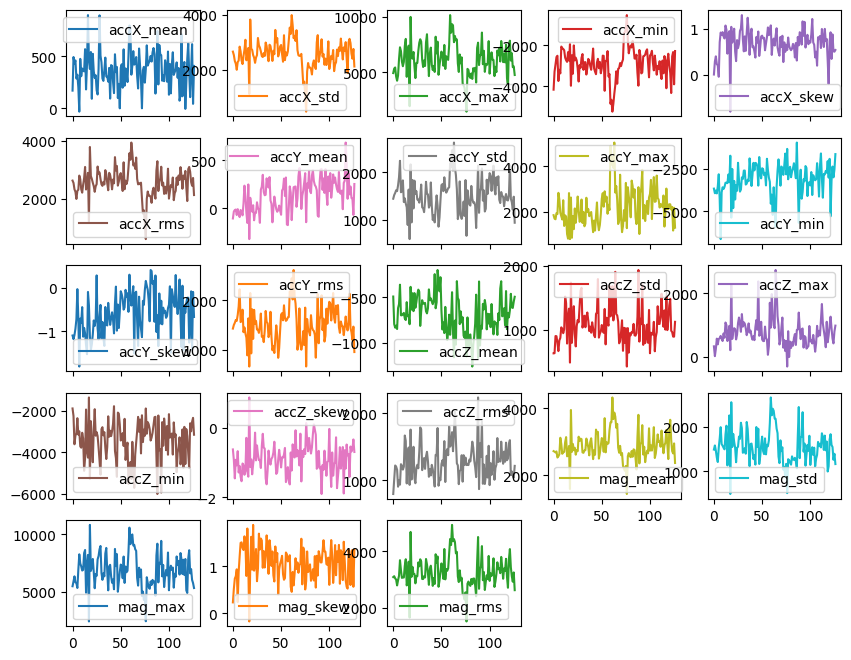

In [15]:
# lav et plot over features
features_jabs_df.plot(subplots=True,layout=(5,5),figsize=(10, 8))
plt.show()

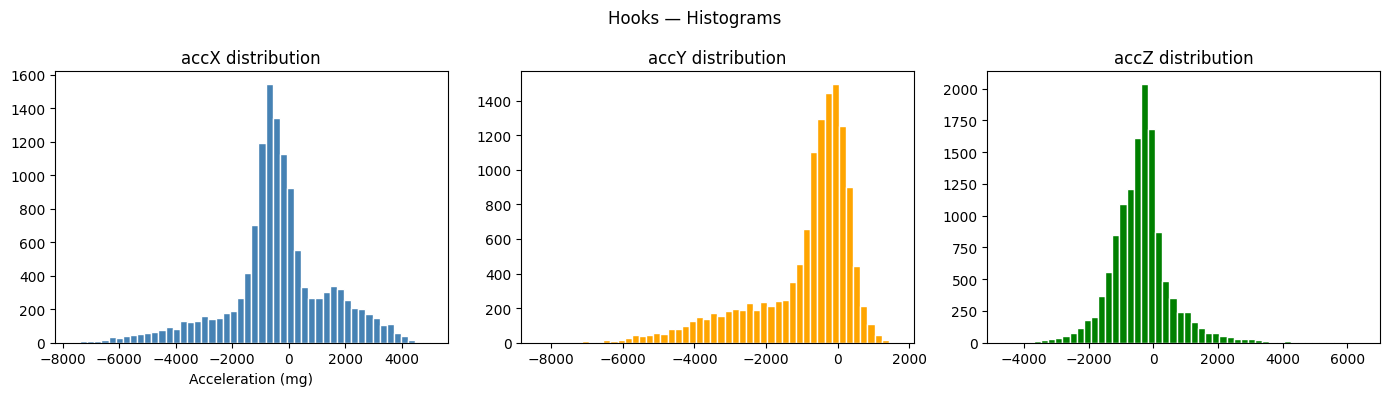

In [16]:
# her starter hooks analyse

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_hooks['accX'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('accX distribution')
axes[0].set_xlabel('Acceleration (mg)')

axes[1].hist(df_hooks['accY'], bins=50, color='orange', edgecolor='white')
axes[1].set_title('accY distribution')

axes[2].hist(df_hooks['accZ'], bins=50, color='green', edgecolor='white')
axes[2].set_title('accZ distribution')

plt.suptitle('Hooks — Histograms')
plt.tight_layout()
plt.show()

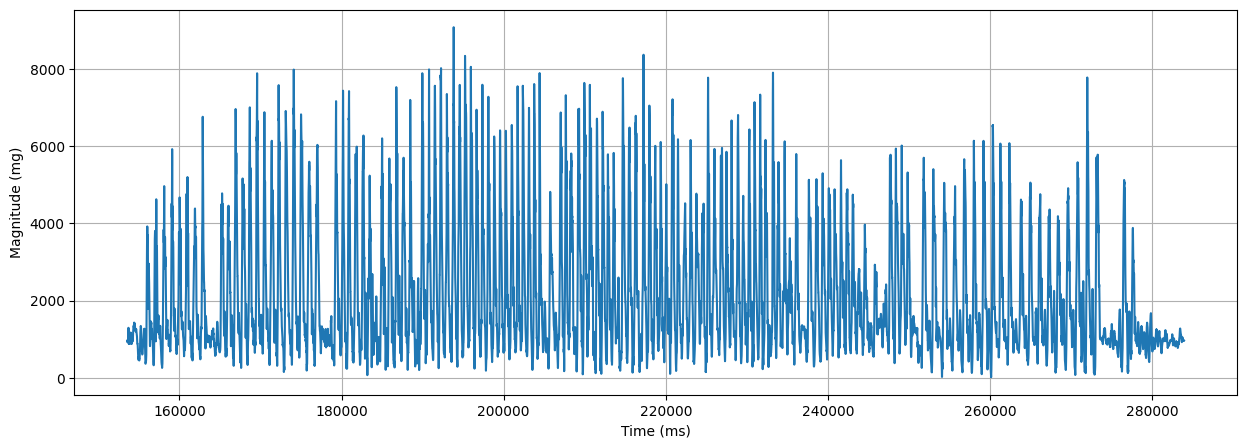

In [17]:
# udregner magnitude, er godt nok gjort i c++ men udregnet for at være sikker på at det er korrekt og for at kunne plotte det i python
df_hooks["mag"] = np.sqrt(
    df_hooks["accX"]**2 +
    df_hooks["accY"]**2 +
    df_hooks["accZ"]**2
)

plt.figure(figsize=(15,5))
plt.plot(df_hooks["timestamp"], df_hooks["mag"])
plt.ylabel("Magnitude (mg)")
plt.xlabel("Time (ms)")
plt.grid()
plt.show()

In [18]:
#find peaks i dataen, det er her der er slag

from scipy.signal import find_peaks

peaks, properties = find_peaks(
    df_hooks["mag"],
    height=2000,      # minimum peak
    distance=50       # mindst 50 samples mellem slag
)

print("Antal peaks:", len(peaks))

Antal peaks: 138


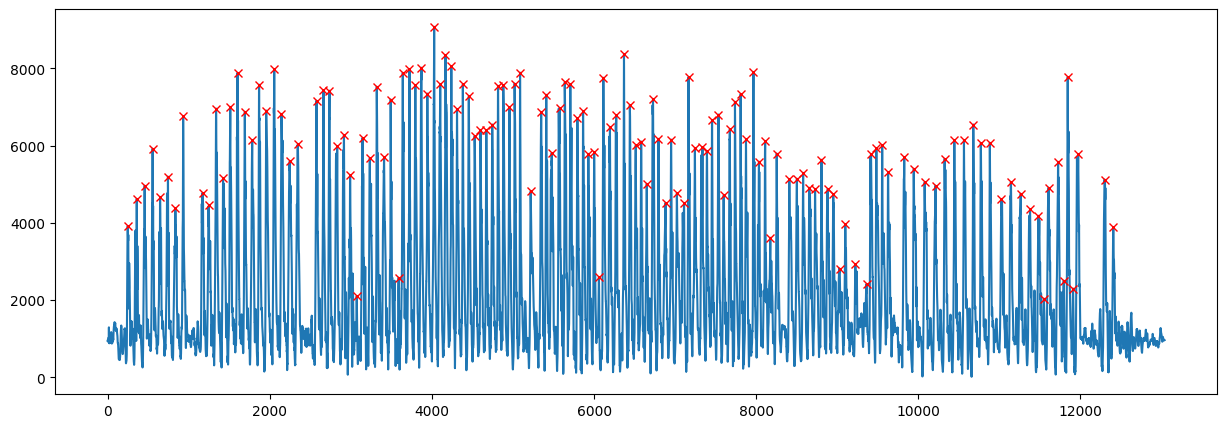

In [19]:
plt.figure(figsize=(15,5))

plt.plot(df_hooks["mag"])
plt.plot(peaks,
         df_hooks["mag"].loc[peaks],
         "rx")

plt.show()

In [20]:
# klipper hvert slag ud i et vindue, size kan variere afhængig af hvor lange slagene er
BEFORE_PEAK = 20  # hvor mange samples før peak
AFTER_PEAK = 20   # hvor mange samples efter peak
segments_hooks = []

for peak in peaks:
    start = peak - BEFORE_PEAK
    end = peak + AFTER_PEAK
    
    if start < 0:
        continue
    if end > len(df_hooks):
        continue
    
    segment = df_hooks.iloc[start:end].copy()
    segments_hooks.append(segment)
    
print(f"Antal segmenter: {len(segments_hooks)}")

Antal segmenter: 138


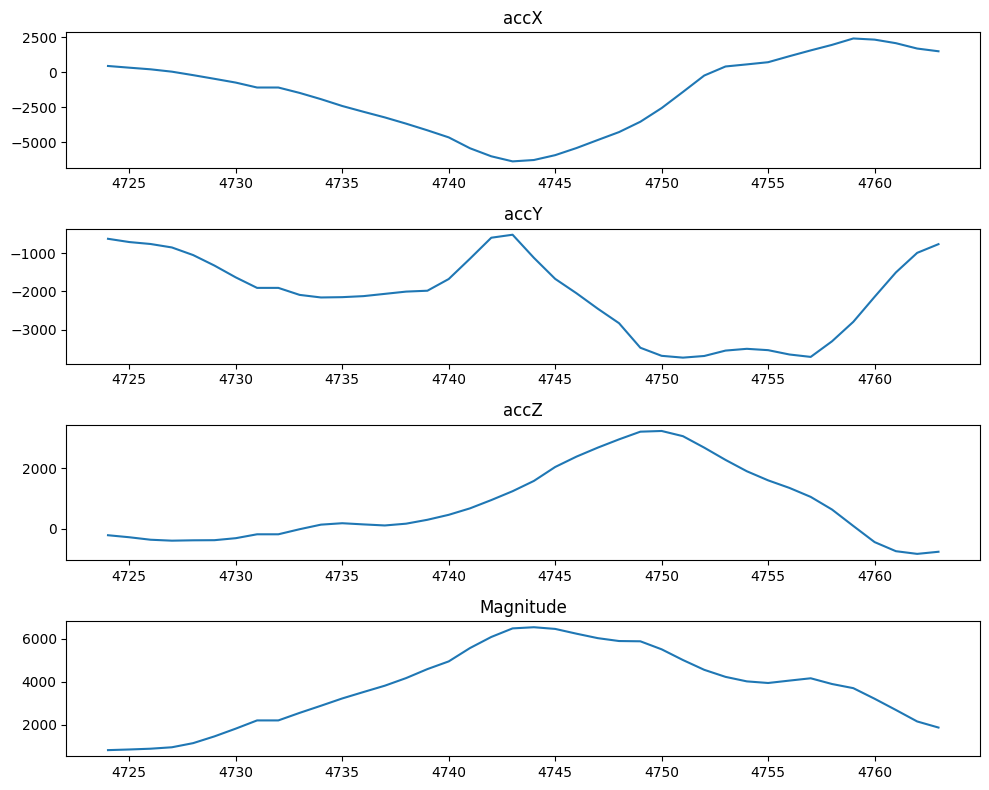

In [21]:
seg = segments_hooks[50]  # eksempel på et segment

fig, axes = plt.subplots(4,1, figsize=(10,8))

axes[0].plot(seg["accX"])
axes[0].set_title("accX")

axes[1].plot(seg["accY"])
axes[1].set_title("accY")

axes[2].plot(seg["accZ"])
axes[2].set_title("accZ")

axes[3].plot(seg["mag"])
axes[3].set_title("Magnitude")

plt.tight_layout()
plt.show()

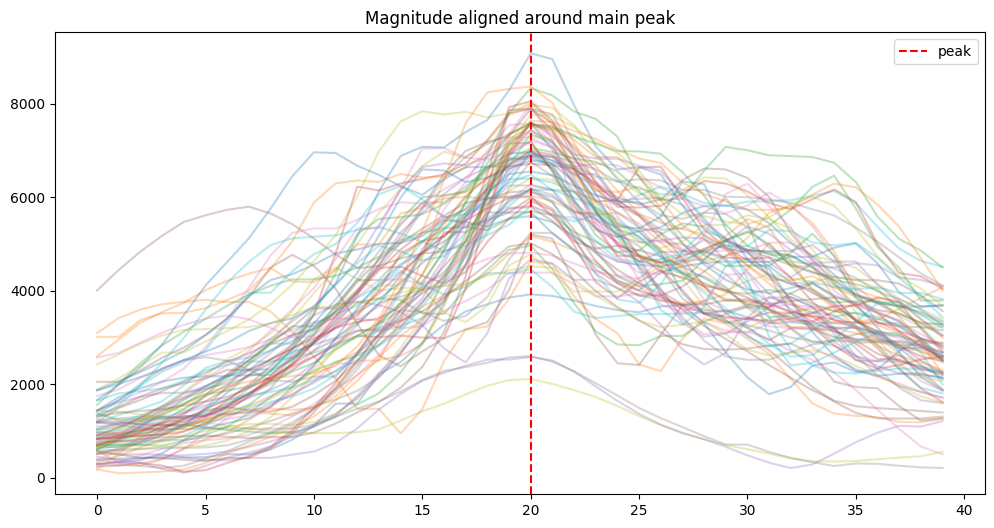

In [22]:
plt.figure(figsize=(12, 6))

for seg in segments_hooks[:80]:
    plt.plot(seg["mag"].values, alpha=0.3)

plt.axvline(BEFORE_PEAK, color="red", linestyle="--", label="peak")
plt.legend()
plt.title("Magnitude aligned around main peak")
plt.show()

In [23]:
features_hooks = []

for seg in segments_hooks:
    features_hooks.append(extract_features(seg))
    
features_hooks_df = pd.DataFrame(features_hooks, columns=feature_names)
features_hooks_df["label"] = "hook"
#features_hooks_df.head()


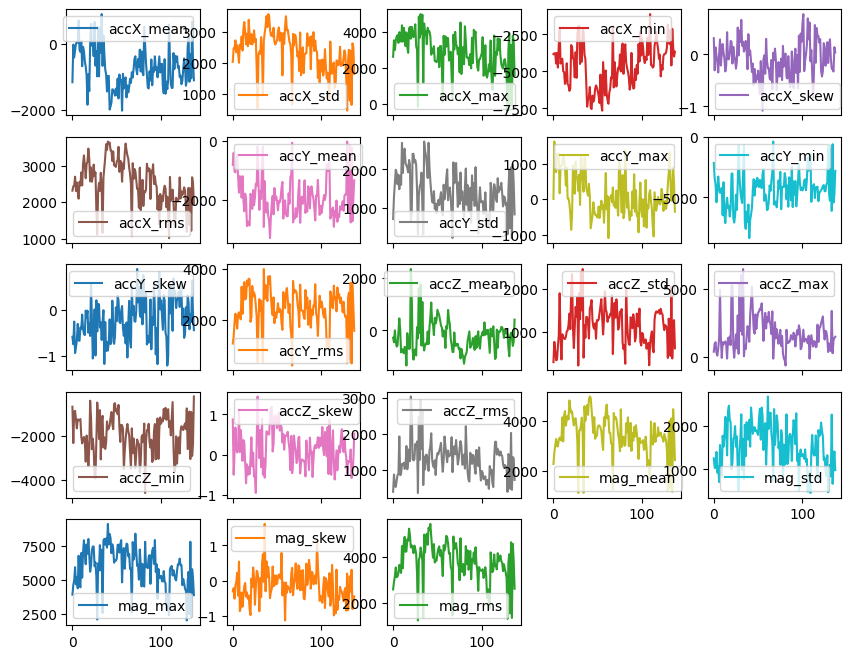

In [24]:
# laver plottet over hooks features
features_hooks_df.plot(subplots=True,layout=(5,5),figsize=(10, 8))
plt.show()

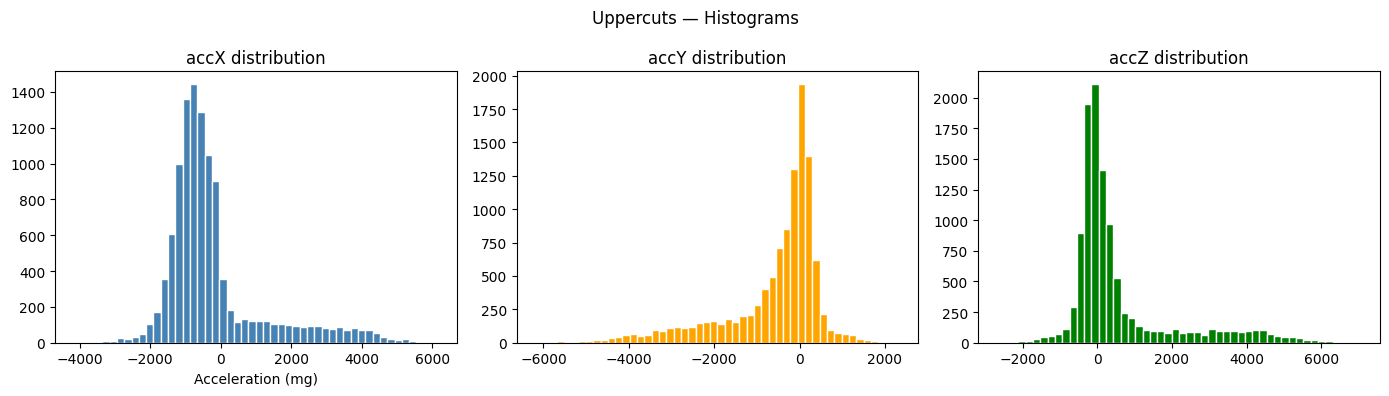

In [25]:
# analyse af uppercuts starter her, samme procedure som for jabs og hooks
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_uppercuts['accX'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('accX distribution')
axes[0].set_xlabel('Acceleration (mg)')

axes[1].hist(df_uppercuts['accY'], bins=50, color='orange', edgecolor='white')
axes[1].set_title('accY distribution')

axes[2].hist(df_uppercuts['accZ'], bins=50, color='green', edgecolor='white')
axes[2].set_title('accZ distribution')

plt.suptitle('Uppercuts — Histograms')
plt.tight_layout()
plt.show()

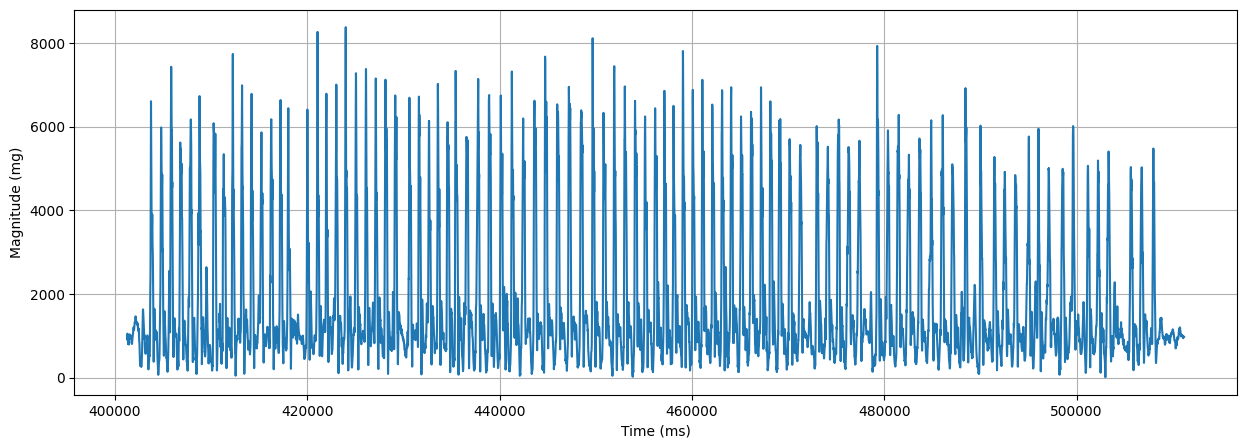

In [26]:
df_uppercuts["mag"] = np.sqrt(
    df_uppercuts["accX"]**2 +
    df_uppercuts["accY"]**2 +
    df_uppercuts["accZ"]**2
)

plt.figure(figsize=(15,5))
plt.plot(df_uppercuts["timestamp"], df_uppercuts["mag"])
plt.ylabel("Magnitude (mg)")
plt.xlabel("Time (ms)")
plt.grid()
plt.show()

In [27]:
peaks, properties = find_peaks(
    df_uppercuts["mag"],
    height=2000,      # minimum peak
    distance=50       # mindst 50 samples mellem slag
)

print("Antal peaks:", len(peaks))

Antal peaks: 98


In [28]:
BEFORE_PEAK = 20  # hvor mange samples før peak
AFTER_PEAK = 15   # hvor mange samples efter peak
segments_uppercuts = []

for peak in peaks:
    start = peak - BEFORE_PEAK
    end = peak + AFTER_PEAK
    
    if start < 0:
        continue
    if end > len(df_uppercuts):
        continue
    
    segment = df_uppercuts.iloc[start:end].copy()
    segments_uppercuts.append(segment)
    
print(f"Antal segmenter: {len(segments_uppercuts)}")

Antal segmenter: 98


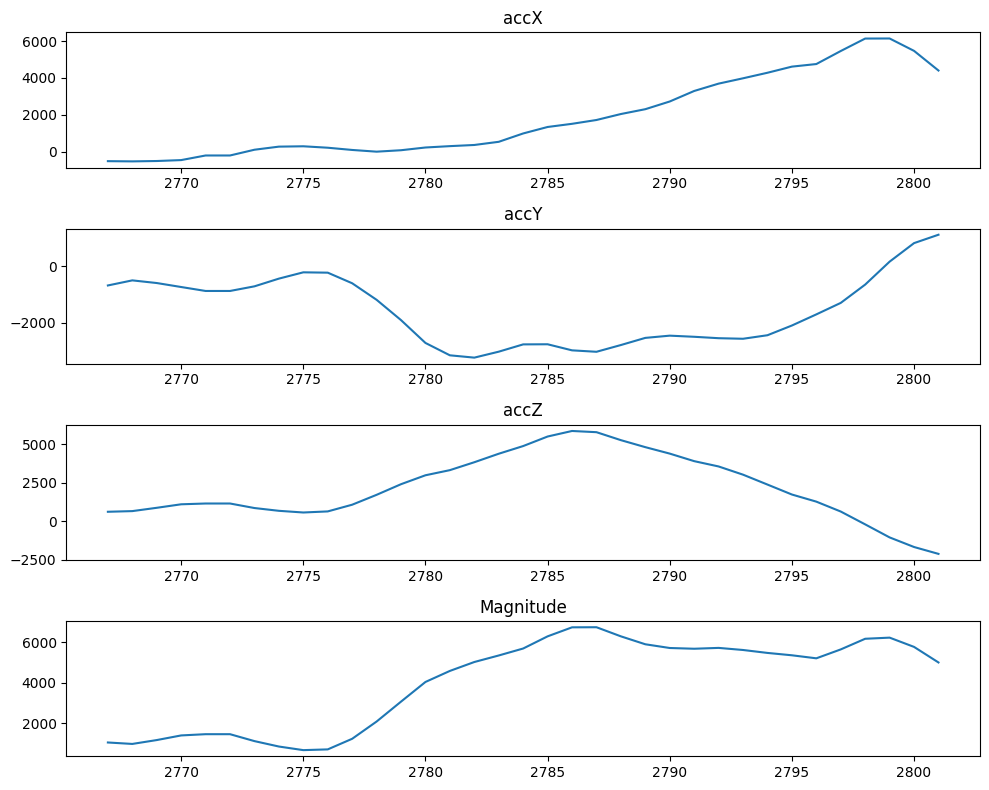

In [29]:
seg = segments_uppercuts[25]  # eksempel på et segment

fig, axes = plt.subplots(4,1, figsize=(10,8))

axes[0].plot(seg["accX"])
axes[0].set_title("accX")

axes[1].plot(seg["accY"])
axes[1].set_title("accY")

axes[2].plot(seg["accZ"])
axes[2].set_title("accZ")

axes[3].plot(seg["mag"])
axes[3].set_title("Magnitude")

plt.tight_layout()
plt.show()

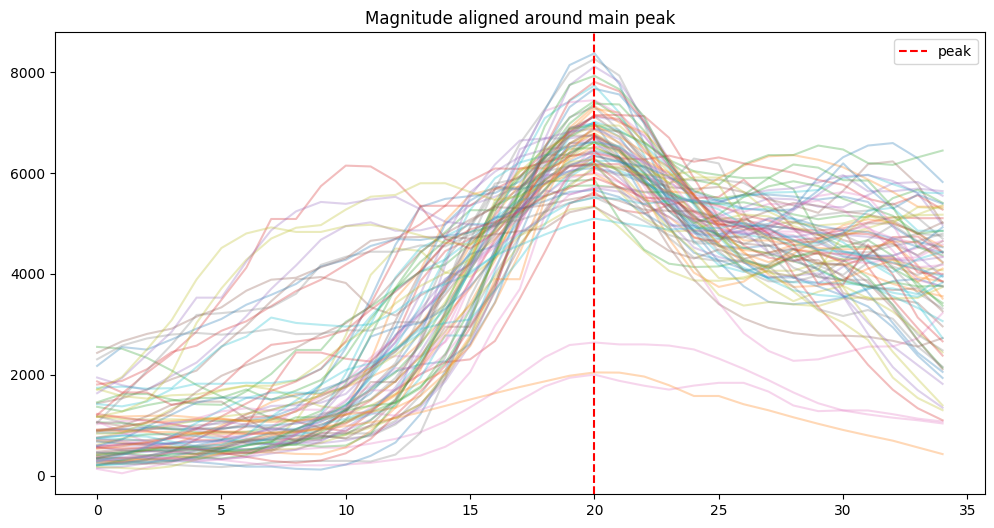

In [30]:
plt.figure(figsize=(12, 6))

for seg in segments_uppercuts[:80]:
    plt.plot(seg["mag"].values, alpha=0.3)

plt.axvline(BEFORE_PEAK, color="red", linestyle="--", label="peak")
plt.legend()
plt.title("Magnitude aligned around main peak")
plt.show()

In [31]:
features_uppercuts = []

for seg in segments_uppercuts:
    features_uppercuts.append(extract_features(seg))
    
features_uppercuts_df = pd.DataFrame(features_uppercuts, columns=feature_names)
features_uppercuts_df["label"] = "uppercut"
#features_uppercuts_df.head()

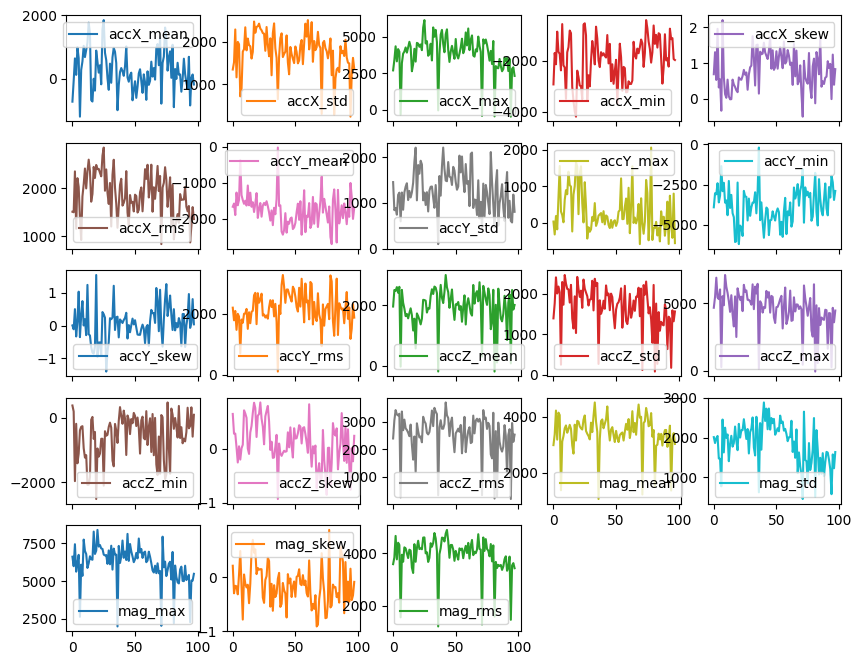

In [32]:
features_uppercuts_df.plot(subplots=True,layout=(5,5),figsize=(10, 8))
plt.show()

In [33]:
all_features = pd.concat([
    features_jabs_df,
    features_hooks_df,
    features_uppercuts_df
], ignore_index=True)


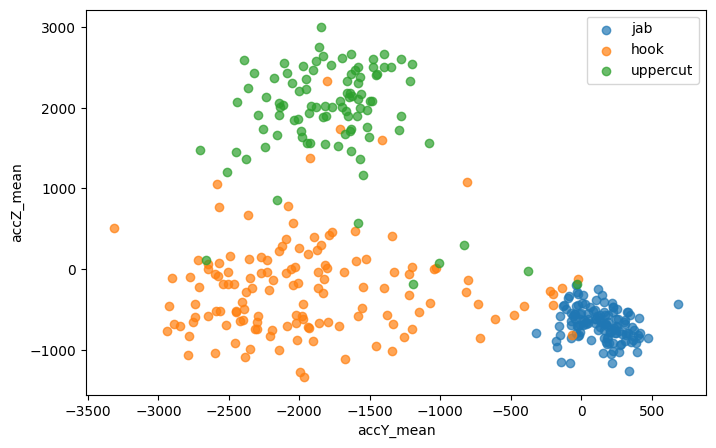

In [34]:
plt.figure(figsize=(8,5))

for label in all_features["label"].unique():

    subset = all_features[
        all_features["label"] == label
    ]

    plt.scatter(
        subset["accY_mean"],
        subset["accZ_mean"],
        label=label,
        alpha=0.7
    )

plt.xlabel("accY_mean")
plt.ylabel("accZ_mean")
plt.legend()
plt.show()

In [35]:
all_features.head()

,accX_mean,accX_std,accX_max,accX_min,accX_skew,accX_rms,accY_mean,accY_std,accY_max,accY_min,...,accZ_max,accZ_min,accZ_skew,accZ_rms,mag_mean,mag_std,mag_max,mag_skew,mag_rms,label
0,169.800000,2656.220499,4949,-4175,0.008771,2623.500230,-107.457143,1441.750128,1847,-3667,...,332,-1886,-0.624105,794.458756,2720.034225,1486.356012,5490.751770,0.229077,3089.452836,jab
1,492.828571,2531.800109,5351,-3296,0.292919,2543.570050,-34.000000,1519.830873,1691,-3937,...,23,-2250,-0.931194,1011.102015,2704.372113,1579.484630,5914.913102,0.520167,3120.436032,jab
2,428.085714,2316.745719,5449,-2945,0.403794,2323.190989,-19.228571,1563.643578,1667,-3781,...,250,-3613,-1.455780,1219.705538,2681.133182,1460.430055,6354.772852,0.735428,3043.089276,jab
3,460.171429,2220.855234,4640,-2585,0.235389,2236.746694,-13.942857,1620.721824,1937,-3949,...,574,-3195,-0.922597,1202.726284,2711.376652,1303.239638,5834.895886,0.784241,3000.245028,jab
4,286.171429,1999.555531,4265,-2523,0.205629,1991.452105,-71.257143,1602.674389,1898,-3539,...,394,-3089,-1.081128,1156.818889,2528.887660,1204.382733,5753.235872,0.931549,2793.629651,jab


In [36]:
# decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree

X = all_features.drop("label", axis=1)
Y = all_features["label"]

selected_features = [
    "accY_mean",
    "accZ_max",
    "accY_max",
    "accX_min",
    "accX_max",
    "accZ_rms"
]


X_train, X_test, Y_train, Y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2,
    random_state=42,
    stratify=Y)


model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Classification Report:\n", classification_report(Y_test, Y_pred))


Accuracy: 0.9178082191780822
Classification Report:
               precision    recall  f1-score   support

        hook       0.96      0.82      0.88        28
         jab       0.96      0.96      0.96        25
    uppercut       0.83      1.00      0.91        20

    accuracy                           0.92        73
   macro avg       0.92      0.93      0.92        73
weighted avg       0.92      0.92      0.92        73



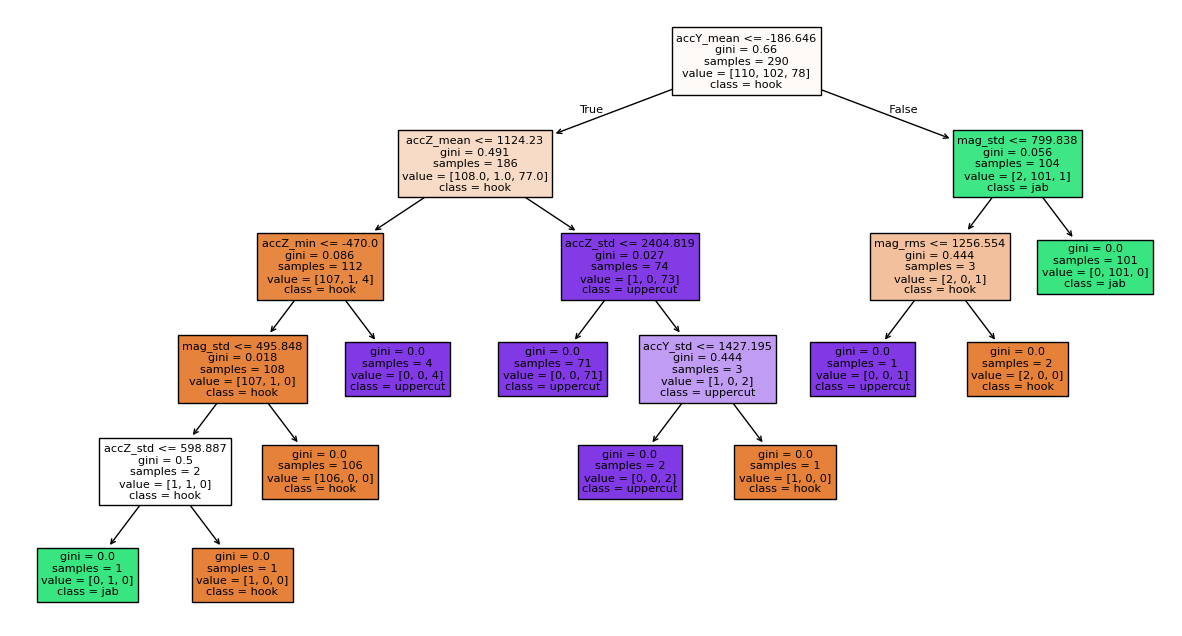

In [37]:
plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.show()

In [38]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# næste linje kan printes
#importance 

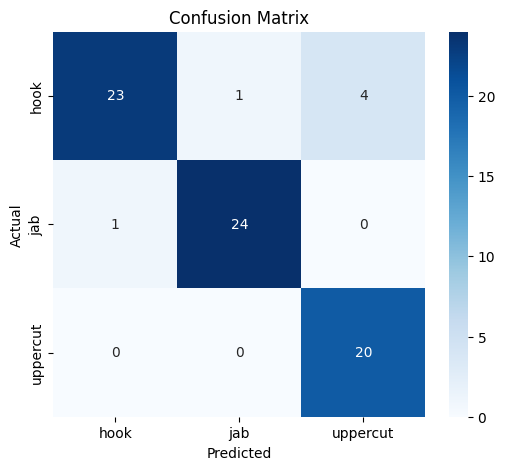

In [39]:
import seaborn as sns

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
#laver en random forest classifier som er tiltænkt skal smides på photon

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=5,max_depth=5, random_state=42)
rf.fit(X_train, Y_train)

Y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, Y_pred))
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance

Accuracy: 0.9315068493150684


,feature,importance
6,accY_mean,0.213187
14,accZ_max,0.119442
21,mag_skew,0.100033
8,accY_max,0.090048
3,accX_min,0.084190
2,accX_max,0.083989
17,accZ_rms,0.070333
15,accZ_min,0.063121
0,accX_mean,0.055085
16,accZ_skew,0.026722


In [41]:
#konvertére modellen så den kan bruges på target
import emlearn
#cmodel = emlearn.convert(rf,method="inline") #kommenter ind når man skal gemme fil
#cmodel.save(file = "boxing_model.h", name="boxing_model")


In [42]:
for i, col in enumerate(X.columns):
    print(f"{i:2d} {col}")

 0 accX_mean
 1 accX_std
 2 accX_max
 3 accX_min
 4 accX_skew
 5 accX_rms
 6 accY_mean
 7 accY_std
 8 accY_max
 9 accY_min
10 accY_skew
11 accY_rms
12 accZ_mean
13 accZ_std
14 accZ_max
15 accZ_min
16 accZ_skew
17 accZ_rms
18 mag_mean
19 mag_std
20 mag_max
21 mag_skew
22 mag_rms


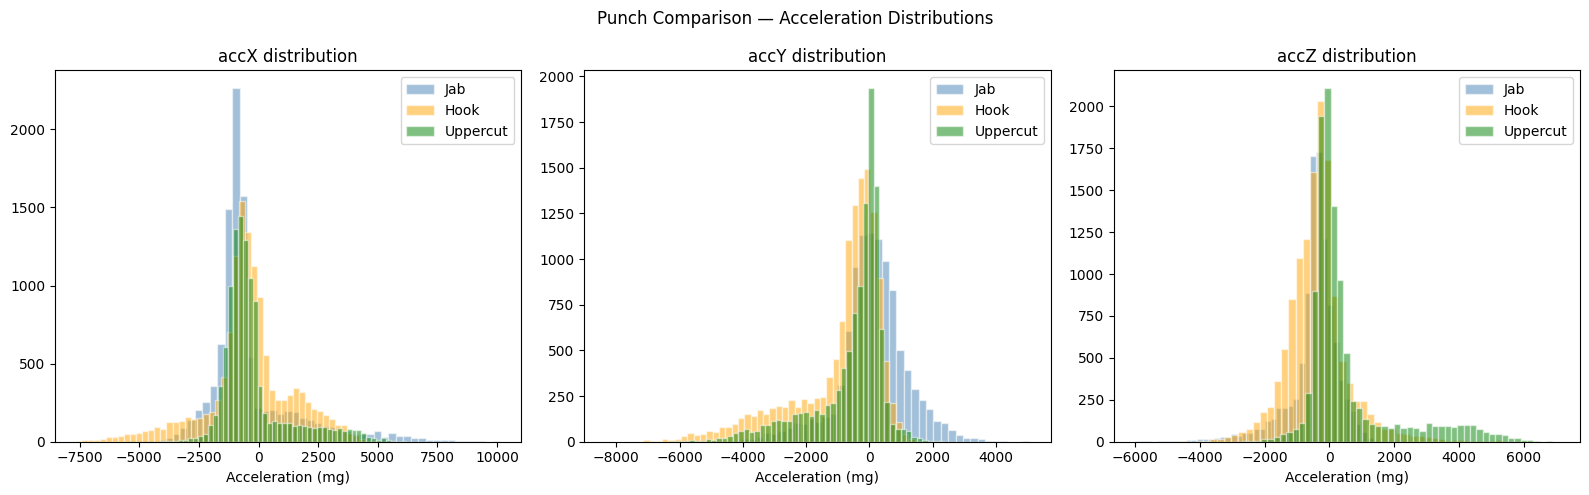

In [43]:
colors = {
    "jab": "steelblue",
    "hook": "orange",
    "uppercut": "green"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))


axes[0].hist(df_jab['accX'], bins=50, alpha=0.5, color=colors["jab"], label="Jab", edgecolor='white')
axes[0].hist(df_hooks['accX'], bins=50, alpha=0.5, color=colors["hook"], label="Hook", edgecolor='white')
axes[0].hist(df_uppercuts['accX'], bins=50, alpha=0.5, color=colors["uppercut"], label="Uppercut", edgecolor='white')
axes[0].set_title("accX distribution")
axes[0].set_xlabel("Acceleration (mg)")
axes[0].legend()

axes[1].hist(df_jab['accY'], bins=50, alpha=0.5, color=colors["jab"], label="Jab", edgecolor='white')
axes[1].hist(df_hooks['accY'], bins=50, alpha=0.5, color=colors["hook"], label="Hook", edgecolor='white')
axes[1].hist(df_uppercuts['accY'], bins=50, alpha=0.5, color=colors["uppercut"], label="Uppercut", edgecolor='white')
axes[1].set_title("accY distribution")
axes[1].set_xlabel("Acceleration (mg)")
axes[1].legend()

axes[2].hist(df_jab['accZ'], bins=50, alpha=0.5, color=colors["jab"], label="Jab", edgecolor='white')
axes[2].hist(df_hooks['accZ'], bins=50, alpha=0.5, color=colors["hook"], label="Hook", edgecolor='white')
axes[2].hist(df_uppercuts['accZ'], bins=50, alpha=0.5, color=colors["uppercut"], label="Uppercut", edgecolor='white')
axes[2].set_title("accZ distribution")
axes[2].set_xlabel("Acceleration (mg)")
axes[2].legend()

plt.suptitle("Punch Comparison — Acceleration Distributions")
plt.tight_layout()
plt.show()

In [44]:

features_to_plot = [
    "accY_mean",
    "accZ_max",
    "accY_max",
    "accX_min",
    "accX_max"
]

fig, axes = plt.subplots(
    len(features_to_plot),
    1,
    figsize=(8,12)
)

for ax, feat in zip(axes, features_to_plot):

    all_features.(
        column=feat,
        by="label",
        ax=ax
    )

    ax.set_title(feat)

plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (4146586224.py, line 17)